In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.geo import add_geo_features
from pathlib import Path

sns.set_style("whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
df = pd.read_csv("data/raw/nekretnine_dataset.csv")

df.head()

,Price_EUR,Square_footage,Number_of_rooms,State,Lift,Heating,Optical_internet,Parking,Floor,Street
0,135000.0,37 m²,2.0,Standardna gradnja,1,NaN,0,0,0,Žarkovo
1,189000.0,83 m²,3.0,Izvorno stanje,1,"Centralno grejanje, Klima uređaj",0,1,4,Miljakovac I
2,174500.0,63 m²,3.0,Novogradnja,0,Etažno grejanje na gas,0,0,3,Karaburma
3,170000.0,61 m²,3.0,Novogradnja,1,Centralno grejanje,0,1,0,Zvezdara
4,135000.0,73 m²,3.0,Novogradnja,0,Ostalo,0,1,3,Krnjača


In [3]:
print(df.shape)

(9619, 10)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9619 entries, 0 to 9618
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price_EUR         9576 non-null   float64
 1   Square_footage    9603 non-null   object 
 2   Number_of_rooms   9492 non-null   float64
 3   State             9457 non-null   object 
 4   Lift              9619 non-null   int64  
 5   Heating           8829 non-null   object 
 6   Optical_internet  9619 non-null   int64  
 7   Parking           9619 non-null   int64  
 8   Floor             9619 non-null   object 
 9   Street            9619 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 751.6+ KB


In [5]:
df.describe()

,Price_EUR,Number_of_rooms,Lift,Optical_internet,Parking
count,9.576000e+03,9492.000000,9619.000000,9619.000000,9619.000000
mean,2.272177e+07,2.937105,0.522300,0.065599,0.291298
std,1.653631e+09,1.213160,0.499528,0.247593,0.454384
min,1.000000e+03,-3.000000,0.000000,0.000000,0.000000
25%,1.499648e+05,2.000000,0.000000,0.000000,0.000000
50%,2.295000e+05,3.000000,1.000000,0.000000,0.000000
75%,3.426528e+05,4.000000,1.000000,0.000000,1.000000
max,1.470304e+11,44.000000,1.000000,1.000000,1.000000


In [6]:
# square footage cleanup
df["Square_footage"] = (
    df["Square_footage"]
    .str.replace(" m²", "", regex=False)
    .astype(float)
)

In [7]:
df.head()

,Price_EUR,Square_footage,Number_of_rooms,State,Lift,Heating,Optical_internet,Parking,Floor,Street
0,135000.0,37.0,2.0,Standardna gradnja,1,NaN,0,0,0,Žarkovo
1,189000.0,83.0,3.0,Izvorno stanje,1,"Centralno grejanje, Klima uređaj",0,1,4,Miljakovac I
2,174500.0,63.0,3.0,Novogradnja,0,Etažno grejanje na gas,0,0,3,Karaburma
3,170000.0,61.0,3.0,Novogradnja,1,Centralno grejanje,0,1,0,Zvezdara
4,135000.0,73.0,3.0,Novogradnja,0,Ostalo,0,1,3,Krnjača


In [8]:
df.isnull().sum()

Price_EUR            43
Square_footage       16
Number_of_rooms     127
State               162
Lift                  0
Heating             790
Optical_internet      0
Parking               0
Floor                 0
Street                0
dtype: int64

In [9]:
#remove missing price 
df = df.dropna(subset=["Price_EUR"])
#remove missing sqaure_footage
df = df.dropna(subset=["Square_footage"])

In [10]:
# fill missing state values
df["State"] = df["State"].fillna("Standardna gradnja")

In [11]:
#fill missing heating values
df["Heating"] = df["Heating"].fillna("Centralno grejanje")

In [12]:
median_m2_per_room = (df["Square_footage"] / df["Number_of_rooms"]).median()
print(median_m2_per_room)

#fill missing room numbers with rounded value of square footage and median of m^2 per room
df.loc[df["Number_of_rooms"].isnull(), "Number_of_rooms"] = (
    df["Square_footage"] / median_m2_per_room
).round()

26.5


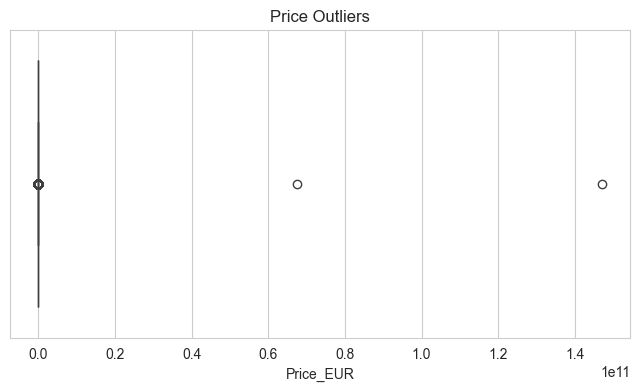

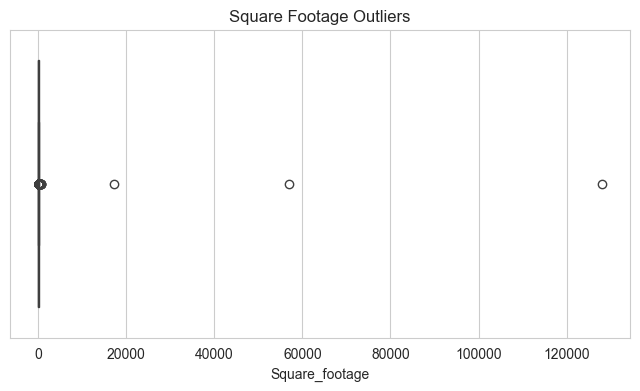

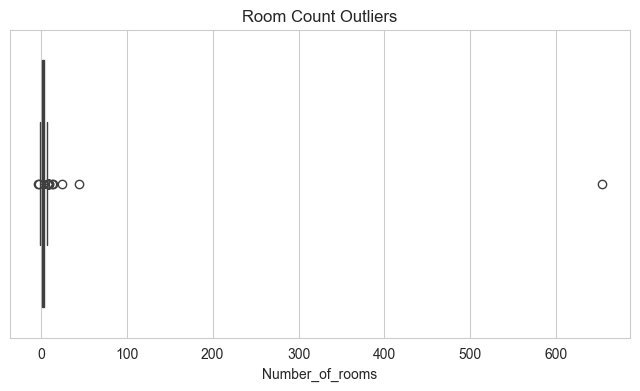

In [13]:
#Checking outliers 
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Price_EUR"])
plt.title("Price Outliers")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x=df["Square_footage"])
plt.title("Square Footage Outliers")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x=df["Number_of_rooms"])
plt.title("Room Count Outliers")
plt.show()

In [14]:
df.sort_values("Price_EUR", ascending=False).head(10)

,Price_EUR,Square_footage,Number_of_rooms,State,Lift,Heating,Optical_internet,Parking,Floor,Street
7811,1.470304e+11,125.00,5.0,U izgradnji,1,Centralno grejanje,1,1,7,Vukov spomenik
8422,6.760032e+10,65.29,2.0,U izgradnji,1,Etažno grejanje na gas,0,0,1,Čukarica
7546,4.250450e+07,46.35,2.0,Novogradnja,1,Centralno grejanje,1,1,0,Savski venac
6510,2.023312e+07,49.05,2.0,U izgradnji,1,Centralno grejanje,0,0,4,Voždovac
8936,7.834992e+06,215.84,5.0,Novogradnja,0,Centralno grejanje,0,0,9,Tošin bunar
7438,5.000000e+06,453.19,5.0,Novogradnja,1,"Centralno grejanje, Klima uređaj",0,1,39,Novi Beograd Blok 65
8932,4.234782e+06,118.29,4.0,Novogradnja,0,Centralno grejanje,0,0,10,Tošin bunar
8912,4.122756e+06,118.47,4.0,Novogradnja,0,Centralno grejanje,0,0,6,Tošin bunar
8900,4.063521e+06,118.47,4.0,Novogradnja,0,Centralno grejanje,0,0,5,Tošin bunar
8913,4.004286e+06,118.47,4.0,Novogradnja,0,Centralno grejanje,0,0,4,Tošin bunar


In [15]:
df.sort_values("Square_footage", ascending=False).head(10)

,Price_EUR,Square_footage,Number_of_rooms,State,Lift,Heating,Optical_internet,Parking,Floor,Street
8538,455000.0,128000.00,5.0,Delimična rekonstrukcija,1,Centralno grejanje,0,0,2,Bežanijska kosa II
1967,205000.0,57000.00,3.0,Lux,0,"Podno grejanje, Kamin",0,1,Prizemlje,Zemun (Gardoš)
9414,2250000.0,17300.00,653.0,Standardna gradnja,0,Ostalo,0,0,0,Galenika
9136,800000.0,650.00,25.0,Novogradnja,0,Etažno grejanje na struju,0,1,Prizemlje,Sopot
133,1500000.0,630.00,4.0,Novogradnja,1,Centralno grejanje,1,1,3,Dedinje (RTV Pink)
9039,285000.0,607.00,6.0,Standardna gradnja,0,Ostalo,0,0,2,Barajevo
9574,1400000.0,541.00,8.0,Standardna gradnja,0,"Klima uređaj, Ostalo",0,0,2,Dedinje (RTV Pink)
7438,5000000.0,453.19,5.0,Novogradnja,1,"Centralno grejanje, Klima uređaj",0,1,39,Novi Beograd Blok 65
9600,970000.0,450.00,5.0,Standardna gradnja,0,"Centralno grejanje, Klima uređaj",0,1,7,Vračar (Centar)
5913,600000.0,420.00,2.0,Standardna gradnja,1,Centralno grejanje,0,0,6,Višnjica


In [16]:
df.sort_values("Number_of_rooms", ascending=False).head(10)

,Price_EUR,Square_footage,Number_of_rooms,State,Lift,Heating,Optical_internet,Parking,Floor,Street
9414,2250000.0,17300.0,653.0,Standardna gradnja,0,Ostalo,0,0,0,Galenika
4966,98900.0,44.0,44.0,Lux,0,Etažno grejanje na struju,1,1,Prizemlje,Ledine
9136,800000.0,650.0,25.0,Novogradnja,0,Etažno grejanje na struju,0,1,Prizemlje,Sopot
9522,1100000.0,369.0,14.0,Izvorno stanje,1,"Klima uređaj, Etažno grejanje na struju, Etažn...",1,1,3,Dedinje (Beli dvor)
3864,195000.0,107.0,13.0,Standardna gradnja,0,Etažno grejanje na struju,0,0,1,Banjica
6560,850000.0,310.0,10.0,Standardna gradnja,0,Centralno grejanje,0,0,5,Trg Republike ( centar )
2334,90000.0,62.0,10.0,Standardna gradnja,0,TA peć,0,0,1,Sremčica
3986,1390000.0,205.0,9.0,Standardna gradnja,1,Centralno grejanje,0,0,4,Knez Mihailova ( centar )
5890,491550.0,226.0,9.0,Novogradnja,0,Centralno grejanje,0,0,0,Ledine
4870,990000.0,239.0,9.0,Standardna gradnja,0,"Centralno grejanje, Klima uređaj",0,0,1,Kalemegdan


In [17]:
# droping extreme outliers
df = df[(df["Square_footage"] >= 15) & (df["Square_footage"] <= 400)]
df = df[(df["Number_of_rooms"] > 0) & (df["Number_of_rooms"] <= 10)]

In [18]:
min_price = 20000
max_price = 2000000
df = df[(df["Price_EUR"] >= min_price) & (df["Price_EUR"] <= max_price)]

In [19]:
# Create price per m2 feature
df["price_per_m2"] = df["Price_EUR"] / df["Square_footage"]

# Drop apartments where price_per_m2 > 11,000
df = df[df["price_per_m2"] <= 11000]

# Check the new dataset
print(df.describe())

          Price_EUR  Square_footage  Number_of_rooms         Lift  \
count  9.489000e+03     9489.000000      9489.000000  9489.000000   
mean   2.865833e+05       81.735410         2.918274     0.521973   
std    2.212040e+05       44.905538         1.129634     0.499543   
min    2.100000e+04       15.000000         0.500000     0.000000   
25%    1.500000e+05       53.000000         2.000000     0.000000   
50%    2.295000e+05       70.000000         3.000000     1.000000   
75%    3.400000e+05       98.340000         4.000000     1.000000   
max    2.000000e+06      400.000000        10.000000     1.000000   

       Optical_internet      Parking  price_per_m2  
count       9489.000000  9489.000000   9489.000000  
mean           0.063231     0.289072   3428.187752  
std            0.243391     0.453355   1288.317969  
min            0.000000     0.000000    399.103139  
25%            0.000000     0.000000   2545.454545  
50%            0.000000     0.000000   3250.000000  
75%    

In [20]:
#dropping outliers for small apartments with large amount of rooms
df.loc[df["Square_footage"] < 70, "Number_of_rooms"] = df.loc[df["Square_footage"] < 70, "Number_of_rooms"].clip(upper=4)

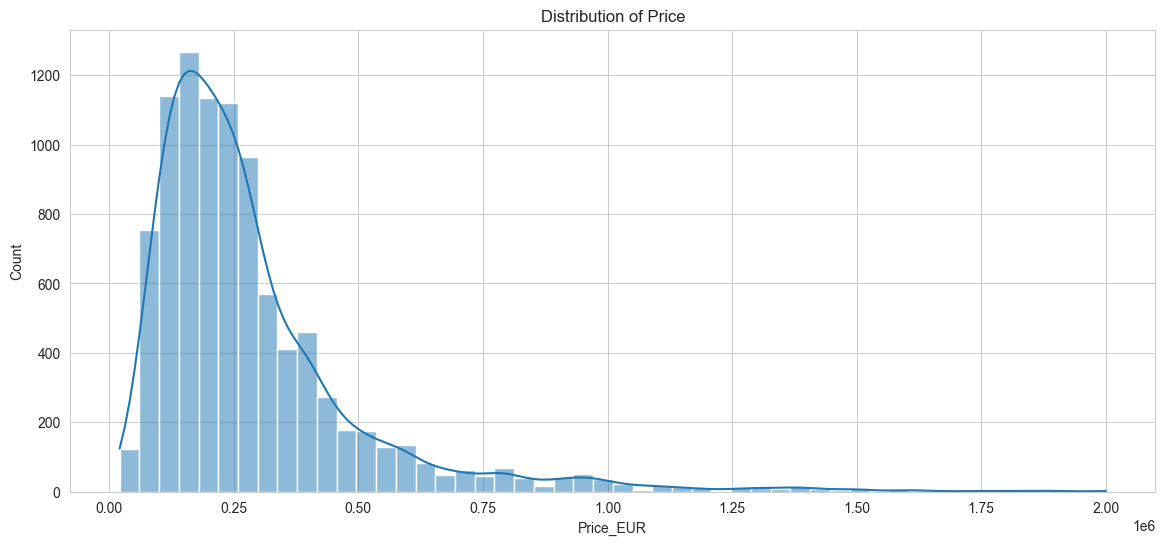

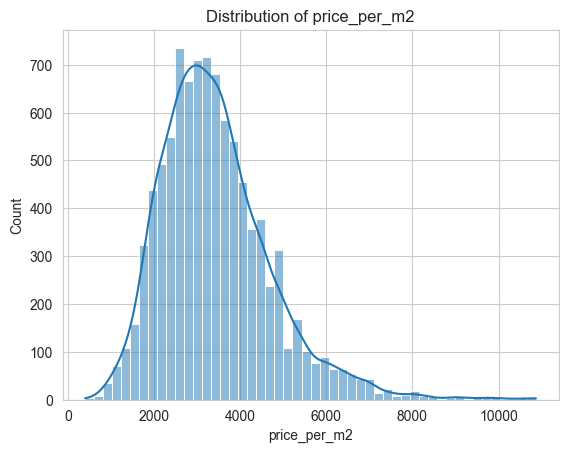

In [21]:
plt.figure(figsize=(14,6))
sns.histplot(df["Price_EUR"], bins=50, kde=True)
plt.title("Distribution of Price")
plt.show()

sns.histplot(df["price_per_m2"], bins=50, kde=True)
plt.title("Distribution of price_per_m2")
plt.show()

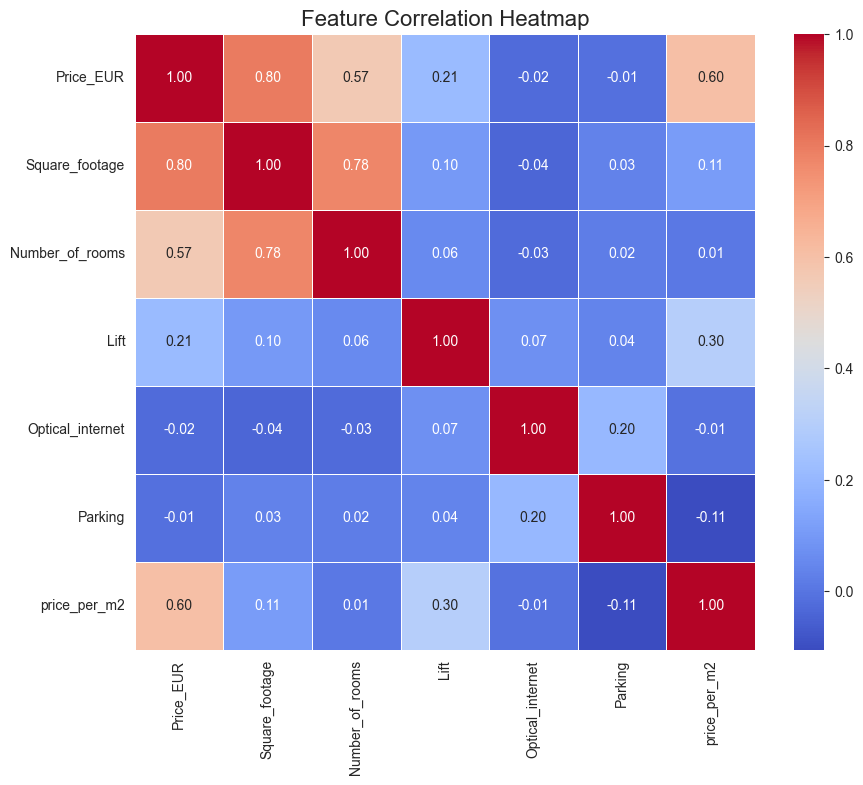

In [22]:
plt.figure(figsize=(10,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap", fontsize=16)
plt.show()

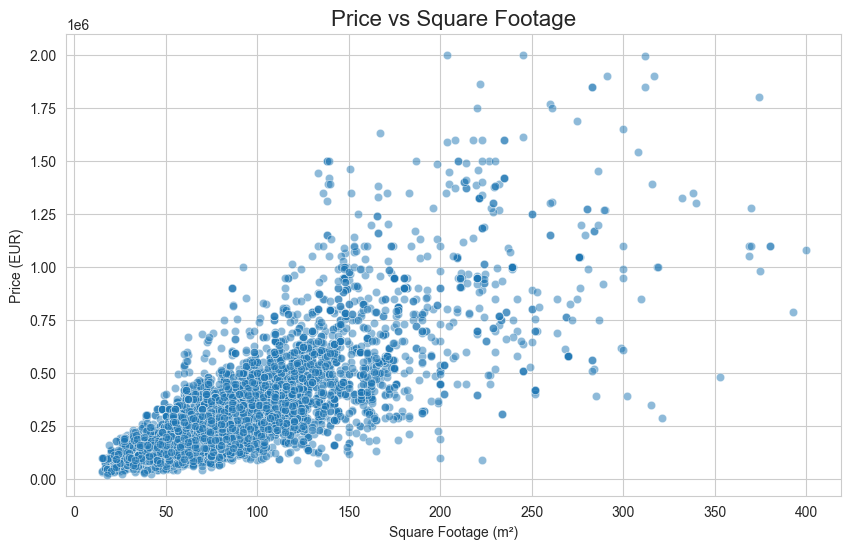

In [23]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="Square_footage",
    y="Price_EUR",
    data=df,
    alpha=0.5
)

plt.title("Price vs Square Footage", fontsize=16)
plt.xlabel("Square Footage (m²)")
plt.ylabel("Price (EUR)")
plt.show()

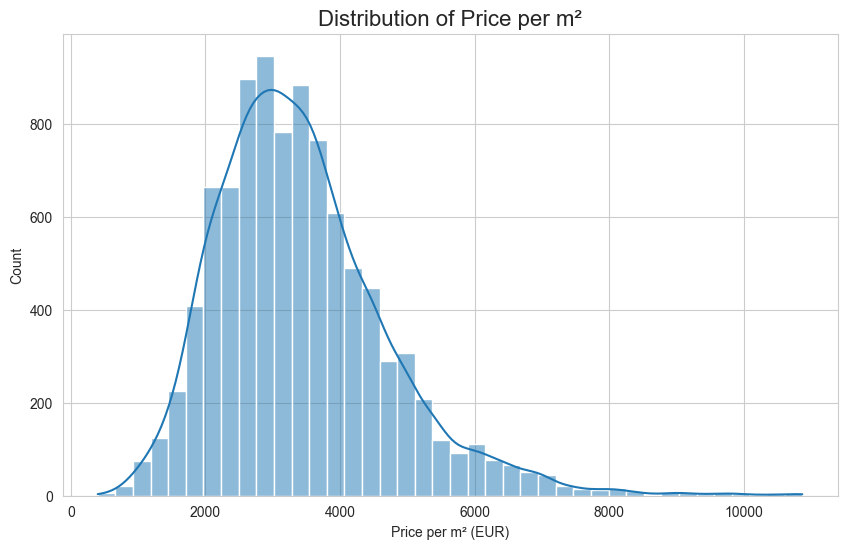

In [24]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["price_per_m2"],
    bins=40,
    kde=True
)

plt.title("Distribution of Price per m²", fontsize=16)
plt.xlabel("Price per m² (EUR)")
plt.show()

In [25]:
df["State"].unique()

array(['Standardna gradnja', 'Izvorno stanje', 'Novogradnja', 'Lux',
       'Kompletna rekonstrukcija', 'U izgradnji', 'Završena izgradnja',
       'Delimična rekonstrukcija', 'U pripremi'], dtype=object)

In [26]:
df["Heating"].unique()

array(['Centralno grejanje', 'Centralno grejanje, Klima uređaj',
       'Etažno grejanje na gas', 'Ostalo', 'Toplotna pumpa',
       'Klima uređaj, Etažno grejanje na struju',
       'Etažno grejanje na struju', 'TA peć',
       'Podno grejanje, Toplotna pumpa', 'Klima uređaj',
       'Klima uređaj, Etažno grejanje na gas', 'Klima uređaj, Ostalo',
       'Centralno grejanje, Klima uređaj, Podno grejanje',
       'Podno grejanje',
       'Klima uređaj, Etažno grejanje na gas, Podno grejanje, Ostalo',
       'Klima uređaj, Podno grejanje',
       'Etažno grejanje na gas, Etažno grejanje na čvrsto gorivo',
       'Etažno grejanje na gas, Podno grejanje', 'TA peć, Klima uređaj',
       'Etažno grejanje na struju, Etažno grejanje na gas',
       'Klima uređaj, Etažno grejanje na struju, Podno grejanje',
       'Klima uređaj, Etažno grejanje na struju, Ostalo',
       'TA peć, Ostalo', 'Etažno grejanje na čvrsto gorivo',
       'Centralno grejanje, Toplotna pumpa',
       'Centralno grejanje

In [27]:
df["Street"].unique()

array(['Žarkovo', 'Miljakovac I', 'Karaburma', 'Zvezdara', 'Krnjača',
       'Medaković I', 'Vračar (Centar)', 'Novi Beograd Blok 12 (YUBC)',
       'Autokomanda', 'Voždovac', 'Donji Dorćol', 'Šumice', 'Crveni krst',
       'Južni bulevar', 'Rakovica', 'Mirijevo II', 'Centar (uži)',
       'Novi Beograd Blok 65', 'Novi Beograd Blok 29', 'Čukarička padina',
       'Botanička bašta', 'Slavujev venac', 'Novi Beograd Blok 30 (B92)',
       'Lion', 'Senjak', 'Beograd na vodi', 'Tašmajdan', 'Sunčana padina',
       'Bulbuder', 'Slavija', 'Gornji Dorćol', 'Bežanijska kosa I',
       'Stepa Stepanović', 'Novi Beograd Blok 71', 'Hadžipopovac',
       'Zemun (Gornji grad)', 'Kluz', 'Lekino brdo',
       'Novi Beograd Blok 72', 'Severni bulevar', 'Novi Beograd Blok 63',
       'Banovo brdo', 'Poštanska štedionica', 'Mirijevo I', 'Julino brdo',
       'Braće Jerković', 'Novi Beograd Blok 9a (Dom Zdravlja)',
       'Novi Beograd Blok 3', 'Mirijevo III', 'Kaluđerica', 'Mirijevo IV',
       'Zemun (S

In [28]:
#Categorize the state feature
state_map = {
    "Novogradnja": "New",
    "U izgradnji": "New",
    "Završena izgradnja": "New",
    "U pripremi": "New",

    "Standardna gradnja": "Standard",

    "Izvorno stanje": "Needs_renovation",

    "Kompletna rekonstrukcija": "Renovated",
    "Delimična rekonstrukcija": "Renovated",

    "Lux": "Luxury"
}

df["State"] = df["State"].map(state_map)

In [29]:
# Heating categorization
heating_types = [
    "Centralno grejanje",
    "Etažno grejanje na gas",
    "Etažno grejanje na struju",
    "Etažno grejanje na čvrsto gorivo",
    "Podno grejanje",
    "Toplotna pumpa",
    "TA peć",
    "Kamin",
    "Peć na drva/ugalj",
    "Klima uređaj"
]

for heating in heating_types:
    df[f"heating_{heating}"] = df["Heating"].str.contains(heating, na=False).astype(int)

df.drop(columns=["Heating"], inplace=True)

In [30]:
df = add_geo_features(
    df,
    location_col="Street",
    cache_path=Path("geo_cache.csv"),
    user_agent="belgrade_real_estate_model",
    city_hint="Belgrade",
    country_hint="Serbia",
    delay_seconds=1,
    center_lat=44.8167,
    center_lon=20.4600
)

In [31]:
# fix broken coordinates
df = df[
    (df["lat"].between(44.6, 45.0)) &
    (df["lon"].between(20.2, 20.7))
]

In [32]:
# drop this column since its not neccessary(0 missing after droping)
df = df.drop(columns=["geo_missing"])


<Axes: xlabel='dist_to_center_km', ylabel='Price_EUR'>

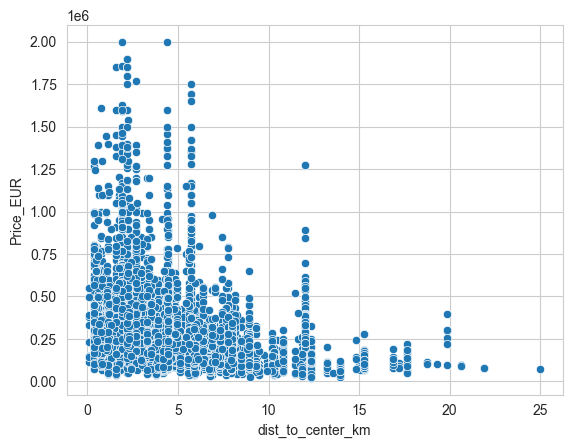

In [33]:
sns.scatterplot(x="dist_to_center_km", y="Price_EUR", data=df)

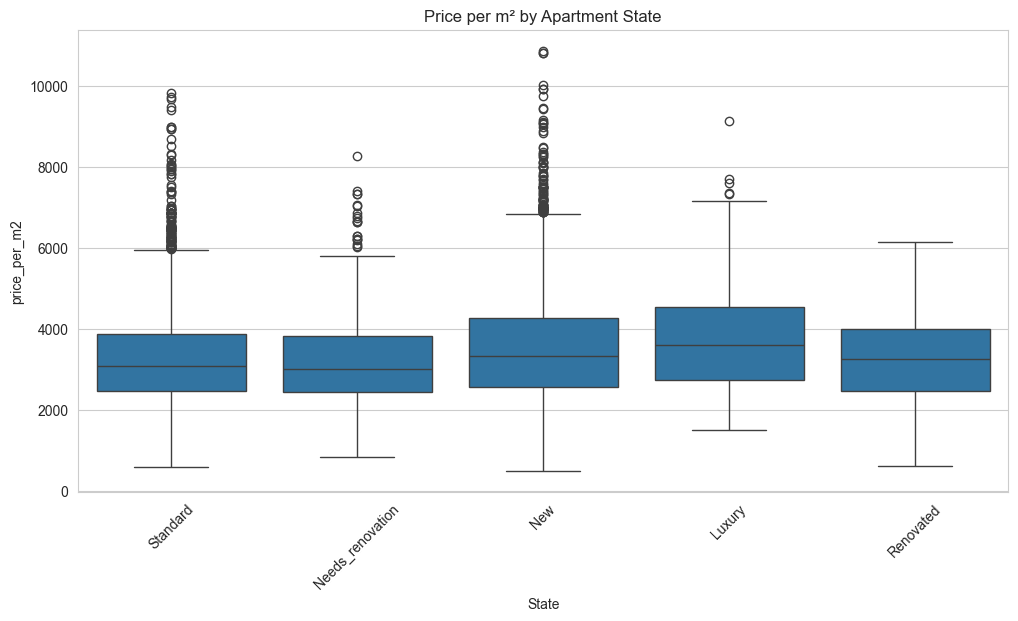

In [34]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="State", y="price_per_m2")
plt.xticks(rotation=45)
plt.title("Price per m² by Apartment State")
plt.show()

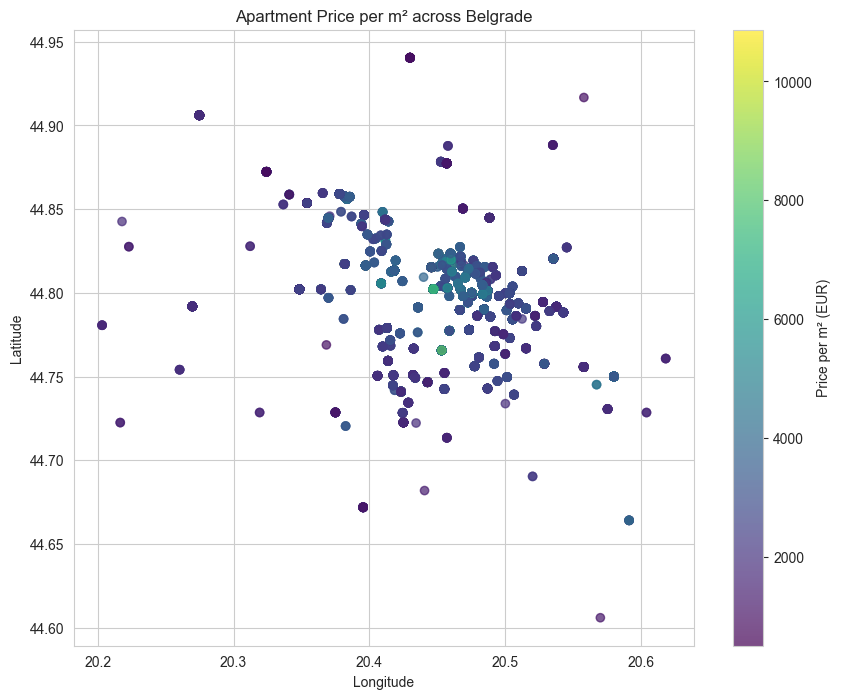

In [35]:

plt.figure(figsize=(10,8))

plt.scatter(
    df["lon"],
    df["lat"],
    c=df["price_per_m2"],
    cmap="viridis",
    alpha=0.7
)

plt.colorbar(label="Price per m² (EUR)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Apartment Price per m² across Belgrade")

plt.show()

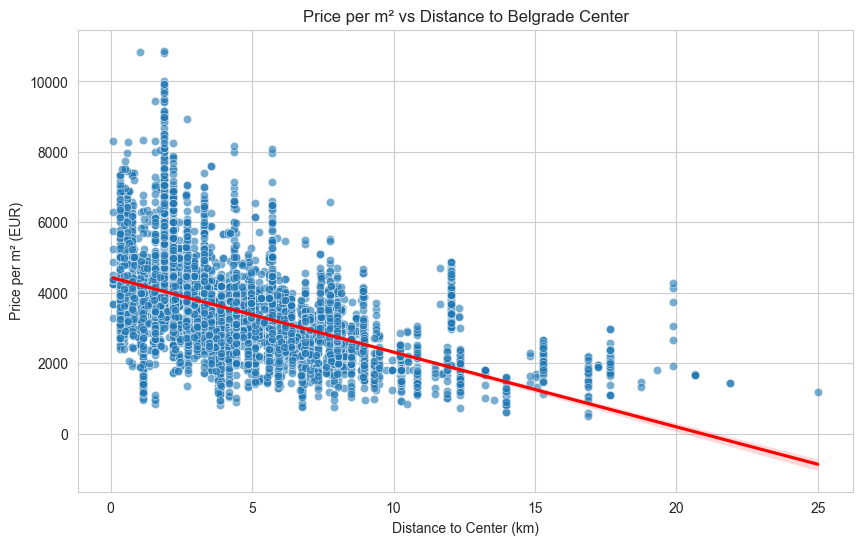

In [36]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="dist_to_center_km",
    y="price_per_m2",
    alpha=0.6
)

sns.regplot(
    data=df,
    x="dist_to_center_km",
    y="price_per_m2",
    scatter=False,
    color="red"
)

plt.title("Price per m² vs Distance to Belgrade Center")
plt.xlabel("Distance to Center (km)")
plt.ylabel("Price per m² (EUR)")

plt.show()

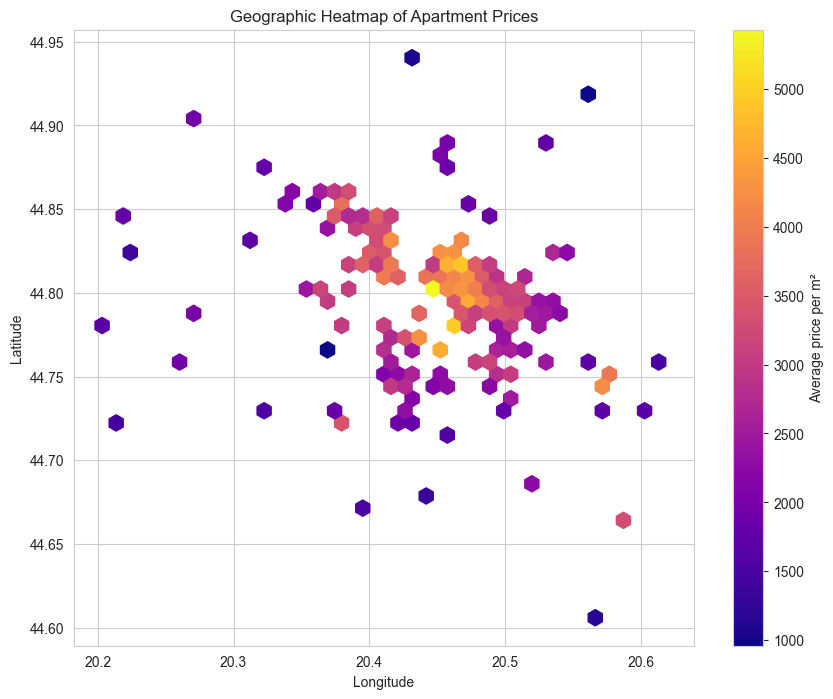

In [37]:
plt.figure(figsize=(10,8))

plt.hexbin(
    df["lon"],
    df["lat"],
    C=df["price_per_m2"],
    gridsize=40,
    cmap="plasma"
)

plt.colorbar(label="Average price per m²")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Heatmap of Apartment Prices")

plt.show()

In [38]:
print(df.columns)

Index(['Price_EUR', 'Square_footage', 'Number_of_rooms', 'State', 'Lift',
       'Optical_internet', 'Parking', 'Floor', 'Street', 'price_per_m2',
       'heating_Centralno grejanje', 'heating_Etažno grejanje na gas',
       'heating_Etažno grejanje na struju',
       'heating_Etažno grejanje na čvrsto gorivo', 'heating_Podno grejanje',
       'heating_Toplotna pumpa', 'heating_TA peć', 'heating_Kamin',
       'heating_Peć na drva/ugalj', 'heating_Klima uređaj', 'lat', 'lon',
       'geo_status', 'dist_to_center_km'],
      dtype='object')


C:\Users\milin\AppData\Local\Temp\ipykernel_21980\3509612509.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heating_zone = df.groupby("zone")[heating_cols].sum()


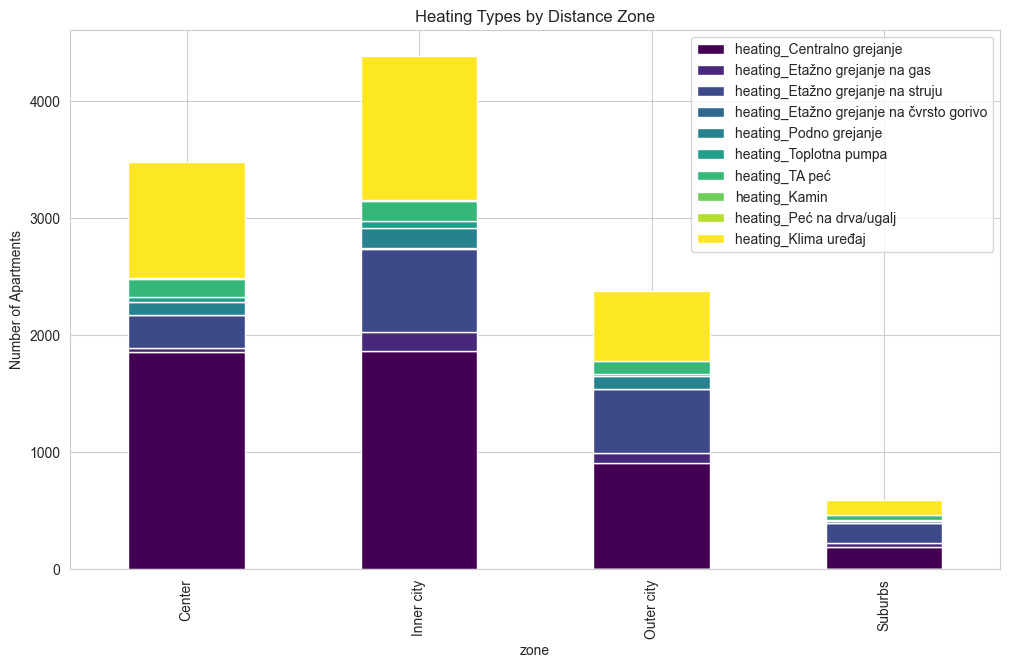

In [39]:
df["zone"] = pd.cut(
    df["dist_to_center_km"],
    bins=[0,3,6,10,25],
    labels=["Center","Inner city","Outer city","Suburbs"]
)

heating_cols = [c for c in df.columns if c.startswith("heating_")]

heating_zone = df.groupby("zone")[heating_cols].sum()

heating_zone.plot(
    kind="bar",
    stacked=True,
    figsize=(12,7),
    colormap="viridis"
)

plt.title("Heating Types by Distance Zone")
plt.ylabel("Number of Apartments")

plt.show()

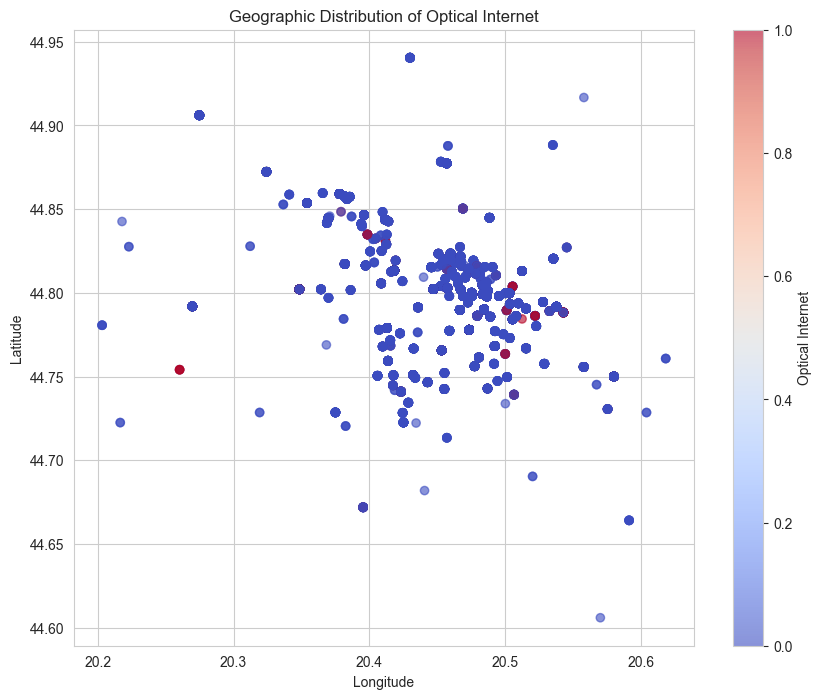

In [40]:
plt.figure(figsize=(10,8))

plt.scatter(
    df["lon"],
    df["lat"],
    c=df["Optical_internet"],
    cmap="coolwarm",
    alpha=0.6
)

plt.colorbar(label="Optical Internet")
plt.title("Geographic Distribution of Optical Internet")

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [41]:
print(df[["dist_to_center_km","Optical_internet"]].corr())

                   dist_to_center_km  Optical_internet
dist_to_center_km           1.000000          0.039644
Optical_internet            0.039644          1.000000


C:\Users\milin\AppData\Local\Temp\ipykernel_21980\3198560782.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  parking_zone = df.groupby("zone")["Parking"].mean()


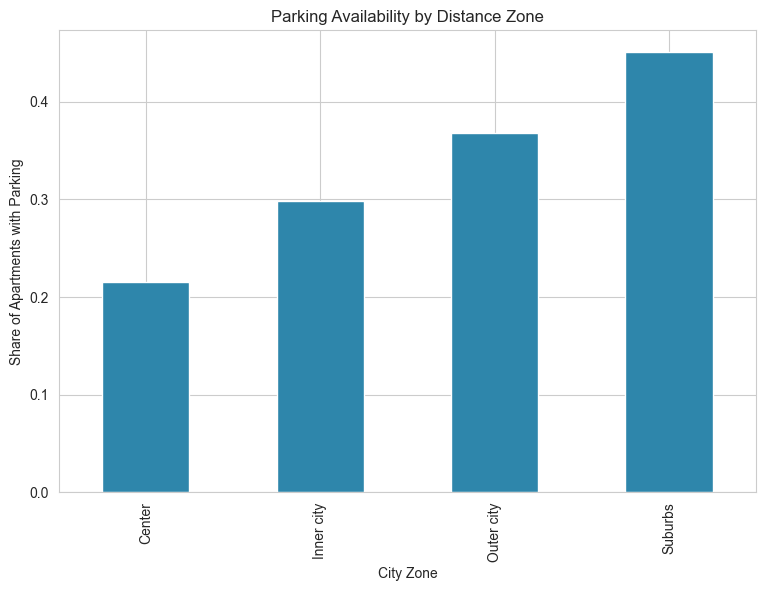

In [42]:
df["zone"] = pd.cut(
    df["dist_to_center_km"],
    bins=[0,3,6,10,25],
    labels=["Center","Inner city","Outer city","Suburbs"]
) 

parking_zone = df.groupby("zone")["Parking"].mean()

plt.figure(figsize=(9,6))

parking_zone.plot(
    kind="bar",
    color="#2E86AB"
)

plt.title("Parking Availability by Distance Zone")
plt.ylabel("Share of Apartments with Parking")
plt.xlabel("City Zone")

plt.show()

C:\Users\milin\AppData\Local\Temp\ipykernel_21980\1255840651.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


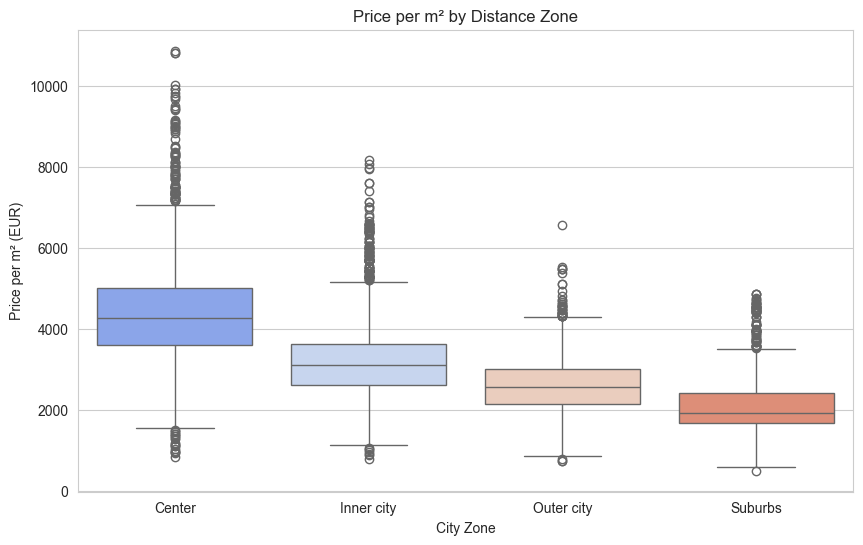

In [43]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="zone",
    y="price_per_m2",
    palette="coolwarm"
)

plt.title("Price per m² by Distance Zone")
plt.ylabel("Price per m² (EUR)")
plt.xlabel("City Zone")

plt.show()

C:\Users\milin\AppData\Local\Temp\ipykernel_21980\2478913557.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lift_zone = df.groupby("zone")["Lift"].mean()


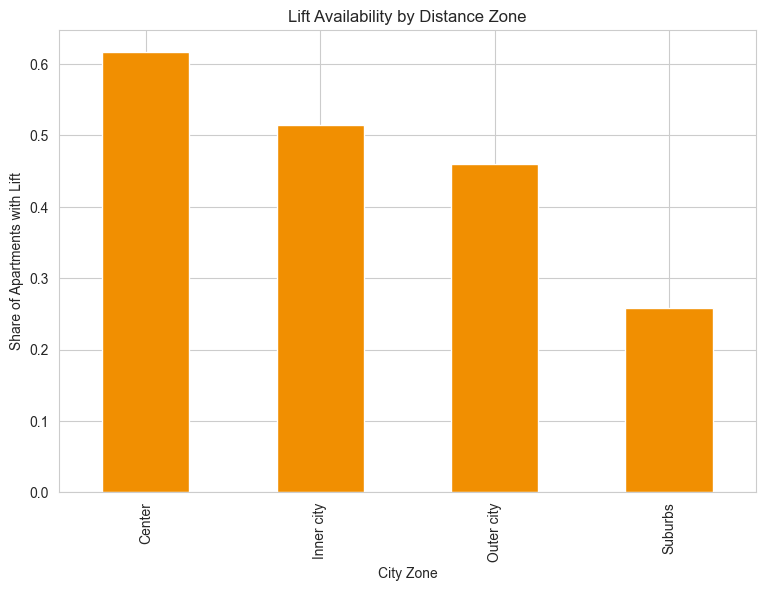

In [44]:
lift_zone = df.groupby("zone")["Lift"].mean()

plt.figure(figsize=(9,6))

lift_zone.plot(
    kind="bar",
    color="#F18F01"
)

plt.title("Lift Availability by Distance Zone")
plt.ylabel("Share of Apartments with Lift")
plt.xlabel("City Zone")

plt.show()

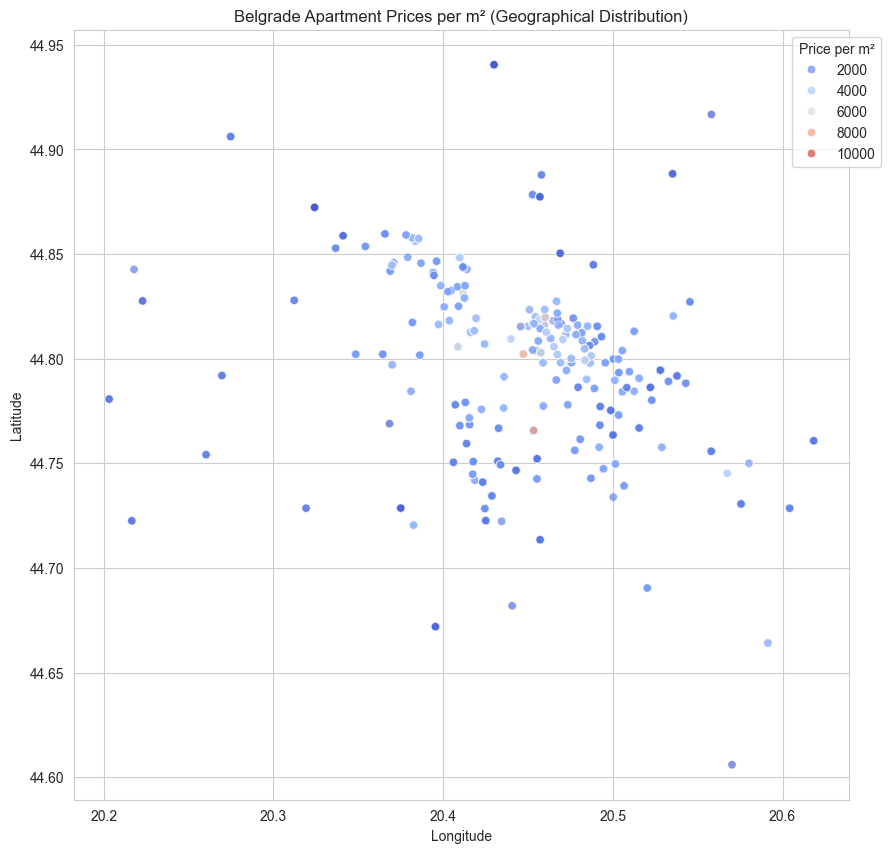

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,10))

sns.scatterplot(
    data=df,
    x="lon",
    y="lat",
    hue="price_per_m2",
    palette="coolwarm",
    alpha=0.7
)

plt.title("Belgrade Apartment Prices per m² (Geographical Distribution)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.legend(title="Price per m²", bbox_to_anchor=(1.05,1))

plt.show()

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8804 entries, 0 to 9617
Data columns (total 25 columns):
 #   Column                                    Non-Null Count  Dtype   
---  ------                                    --------------  -----   
 0   Price_EUR                                 8804 non-null   float64 
 1   Square_footage                            8804 non-null   float64 
 2   Number_of_rooms                           8804 non-null   float64 
 3   State                                     8804 non-null   object  
 4   Lift                                      8804 non-null   int64   
 5   Optical_internet                          8804 non-null   int64   
 6   Parking                                   8804 non-null   int64   
 7   Floor                                     8804 non-null   object  
 8   Street                                    8804 non-null   object  
 9   price_per_m2                              8804 non-null   float64 
 10  heating_Centralno grejanje   

In [47]:
print(df["Floor"].unique())
# Mapping special floor names to numbers
floor_mapping = {
    "Suteren": -1,
    "Prizemlje": 0,
    "Visoko prizemlje": 0.5
}

# Replace mapped values
df["Floor"] = df["Floor"].replace(floor_mapping)

# Convert the rest to float
df["Floor"] = df["Floor"].astype(float)

['0' '4' '3' '2' '1' '5' '7' '6' '9' 'Suteren' 'Prizemlje' '14'
 'Visoko prizemlje' '20' '13' '15' '12' '10' '8' '23' '22' '19' '11' '40'
 '21' '27' '30' '16' '18' '26' '24' '-1' '17' '29' '28' '36' '34' '33'
 '25']


In [48]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import numpy as np

# ── Features & target ──────────────────────────────────────────────────────────
X = df.drop(columns=["Price_EUR", "Street", "zone", "geo_status", "price_per_m2"])
y = df["Price_EUR"]

categorical_cols = ["State"]
numerical_cols = [c for c in X.columns if c not in categorical_cols]

# ── STEP 1: carve out the test set first (20%) ─────────────────────────────────
# This set is NEVER used during hyperparameter tuning — only at final evaluation.
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# ── STEP 2: split the remaining 80% into train (75% of it) + validation (25%)──
# Resulting proportions of the full dataset: train≈60%, val≈20%, test≈20%
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)

print(f"Train size:      {len(X_train):,}")
print(f"Validation size: {len(X_val):,}")
print(f"Test size:       {len(X_test):,}")

# ── Preprocessors ──────────────────────────────────────────────────────────────
preprocessor_scaled = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])

preprocessor_tree = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
], remainder="passthrough", force_int_remainder_cols=False)

# ══════════════════════════════════════════════════════════════════════════════
# 1. LINEAR REGRESSION (baseline — no hyperparameter tuning needed)
# ══════════════════════════════════════════════════════════════════════════════
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("regressor", LinearRegression())
])
lr_pipeline.fit(X_train, y_train)

# Evaluate on validation set
y_pred_lr_val = lr_pipeline.predict(X_val)
print("\n── Linear Regression (Validation) ──")
print(f"MAE:  {mean_absolute_error(y_val, y_pred_lr_val):,.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_pred_lr_val)):,.2f}")
print(f"R²:   {r2_score(y_val, y_pred_lr_val):.4f}")

# Final evaluation on test set
y_pred_lr_test = lr_pipeline.predict(X_test)
print("── Linear Regression (Test) ──")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_lr_test):,.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr_test)):,.2f}")
print(f"R²:   {r2_score(y_test, y_pred_lr_test):.4f}")

# ══════════════════════════════════════════════════════════════════════════════
# 2. DECISION TREE (fixed depth — no search, so validation set not strictly
#    required here, but we still report both for consistency)
# ══════════════════════════════════════════════════════════════════════════════
# 2. DECISION TREE — RandomizedSearchCV na X_train, 3-fold CV
dt_pipeline = Pipeline([
    ("preprocessor", ColumnTransformer(transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ], remainder="passthrough", force_int_remainder_cols=False)),
    ("regressor", DecisionTreeRegressor(random_state=42))
])

param_dist_dt = {
    "regressor__max_depth": [4, 6, 8, 10, 12, None],
    "regressor__min_samples_split": [2, 5, 10, 20],
    "regressor__min_samples_leaf": [1, 2, 4, 8],
    "regressor__max_features": [None, "sqrt", "log2"]
}

random_search_dt = RandomizedSearchCV(
    dt_pipeline,
    param_distributions=param_dist_dt,
    n_iter=30,
    cv=3,
    scoring="r2",
    verbose=1,
    random_state=42,
    n_jobs=-1
)
random_search_dt.fit(X_train, y_train)

print("\nDT best params:", random_search_dt.best_params_)
best_dt = random_search_dt.best_estimator_

y_pred_dt_val  = best_dt.predict(X_val)
y_pred_dt_test = best_dt.predict(X_test)

print("── Decision Tree (Validation) ──")
print(f"MAE: {mean_absolute_error(y_val, y_pred_dt_val):,.2f}  "
      f"RMSE: {np.sqrt(mean_squared_error(y_val, y_pred_dt_val)):,.2f}  "
      f"R²: {r2_score(y_val, y_pred_dt_val):.4f}")
print("── Decision Tree (Test) ──")
print(f"MAE: {mean_absolute_error(y_test, y_pred_dt_test):,.2f}  "
      f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_dt_test)):,.2f}  "
      f"R²: {r2_score(y_test, y_pred_dt_test):.4f}")

# ══════════════════════════════════════════════════════════════════════════════
# 3. RANDOM FOREST — hyperparameter search runs on X_train only (with its own
#    internal 3-fold CV). X_val is used to confirm; X_test is the final report.
# ══════════════════════════════════════════════════════════════════════════════
rf_pipeline = Pipeline([
    ("preprocessor", ColumnTransformer(transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ], remainder="passthrough", force_int_remainder_cols=False)),
    ("regressor", RandomForestRegressor(random_state=42, n_jobs=-1))
])

param_dist_rf = {
    "regressor__n_estimators":    [100, 200, 300, 400],
    "regressor__max_depth":       [None, 10, 20, 30, 40],
    "regressor__min_samples_split": [2, 5, 10],
    "regressor__min_samples_leaf":  [1, 2, 4],
    "regressor__max_features":    [None, "sqrt", "log2"]
}

random_search_rf = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_dist_rf,
    n_iter=30,
    cv=3,                  # 3-fold CV is performed entirely within X_train
    scoring="r2",
    verbose=1,
    random_state=42,
    n_jobs=-1
)
random_search_rf.fit(X_train, y_train)   # ← only X_train, never X_val or X_test

print("\nRF best params:", random_search_rf.best_params_)

best_rf = random_search_rf.best_estimator_

y_pred_rf_val  = best_rf.predict(X_val)
y_pred_rf_test = best_rf.predict(X_test)

print("── Random Forest (Validation) ──")
print(f"MAE:  {mean_absolute_error(y_val,  y_pred_rf_val):,.2f}  "
      f"RMSE: {np.sqrt(mean_squared_error(y_val,  y_pred_rf_val)):,.2f}  "
      f"R²: {r2_score(y_val,  y_pred_rf_val):.4f}")
print("── Random Forest (Test — final, reported once) ──")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_rf_test):,.2f}  "
      f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf_test)):,.2f}  "
      f"R²: {r2_score(y_test, y_pred_rf_test):.4f}")

# ══════════════════════════════════════════════════════════════════════════════
# 4. XGBOOST — same pattern: search on X_train, confirm on X_val, report X_test
# ══════════════════════════════════════════════════════════════════════════════
xgb_pipeline = Pipeline([
    ("preprocessor", ColumnTransformer(transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ], remainder="passthrough", force_int_remainder_cols=False)),
    ("regressor", XGBRegressor(random_state=42, n_jobs=-1,
                               objective="reg:squarederror"))
])

param_dist_xgb = {
    "regressor__n_estimators":      [200, 300, 400, 500, 600],
    "regressor__max_depth":         [4, 5, 6, 7, 8, 10],
    "regressor__learning_rate":     [0.01, 0.03, 0.05, 0.08, 0.1, 0.2],
    "regressor__subsample":         [0.6, 0.7, 0.8, 0.9, 1.0],
    "regressor__colsample_bytree":  [0.6, 0.7, 0.8, 0.9, 1.0],
    "regressor__gamma":             [0, 0.1, 0.2, 0.3],
    "regressor__reg_alpha":         [0, 0.01, 0.1, 1],
    "regressor__reg_lambda":        [1, 1.5, 2, 3]
}

random_search_xgb = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=param_dist_xgb,
    n_iter=50,
    cv=3,                  # internal CV within X_train only
    scoring="r2",
    verbose=1,
    random_state=42,
    n_jobs=-1
)
random_search_xgb.fit(X_train, y_train)   # ← only X_train

print("\nXGB best params:", random_search_xgb.best_params_)

best_xgb = random_search_xgb.best_estimator_

y_pred_xgb_val  = best_xgb.predict(X_val)
y_pred_xgb_test = best_xgb.predict(X_test)

print("── XGBoost (Validation) ──")
print(f"MAE:  {mean_absolute_error(y_val,  y_pred_xgb_val):,.2f}  "
      f"RMSE: {np.sqrt(mean_squared_error(y_val,  y_pred_xgb_val)):,.2f}  "
      f"R²: {r2_score(y_val,  y_pred_xgb_val):.4f}")
print("── XGBoost (Test — final, reported once) ──")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_xgb_test):,.2f}  "
      f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_xgb_test)):,.2f}  "
      f"R²: {r2_score(y_test, y_pred_xgb_test):.4f}")

Train size:      5,282
Validation size: 1,761
Test size:       1,761

── Linear Regression (Validation) ──
MAE:  73,897.15
RMSE: 125,633.86
R²:   0.7121
── Linear Regression (Test) ──
MAE:  62,789.28
RMSE: 97,479.33
R²:   0.7620
Fitting 3 folds for each of 30 candidates, totalling 90 fits

DT best params: {'regressor__min_samples_split': 5, 'regressor__min_samples_leaf': 8, 'regressor__max_features': None, 'regressor__max_depth': 10}
── Decision Tree (Validation) ──
MAE: 57,976.64  RMSE: 101,332.62  R²: 0.8127
── Decision Tree (Test) ──
MAE: 50,983.00  RMSE: 86,792.19  R²: 0.8113
Fitting 3 folds for each of 30 candidates, totalling 90 fits

RF best params: {'regressor__n_estimators': 300, 'regressor__min_samples_split': 2, 'regressor__min_samples_leaf': 1, 'regressor__max_features': None, 'regressor__max_depth': None}
── Random Forest (Validation) ──
MAE:  46,327.28  RMSE: 87,221.76  R²: 0.8612
── Random Forest (Test — final, reported once) ──
MAE:  39,684.36  RMSE: 75,936.54  R²: 0.85

In [49]:
#Feature importance 
def get_feature_names(preprocessor, numerical_cols, categorical_cols):
    cat_features = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_cols)
    return np.concatenate([cat_features, numerical_cols])

In [51]:
def get_feature_names(preprocessor, numerical_cols, categorical_cols):
    cat_features = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_cols)
    return list(cat_features) + list(numerical_cols)

# Decision Tree feature importance
feature_names = get_feature_names(
    best_dt.named_steps["preprocessor"],   # best_dt, ne dt_pipeline
    numerical_cols,
    categorical_cols
)

importances = best_dt.named_steps["regressor"].feature_importances_

feat_imp_dt = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(feat_imp_dt.head(10))

                       feature  importance
5               Square_footage    0.765891
23           dist_to_center_km    0.134696
21                         lat    0.033352
10                       Floor    0.026816
22                         lon    0.018414
7                         Lift    0.005049
2                    State_New    0.004912
11  heating_Centralno grejanje    0.003505
6              Number_of_rooms    0.003131
4               State_Standard    0.002453


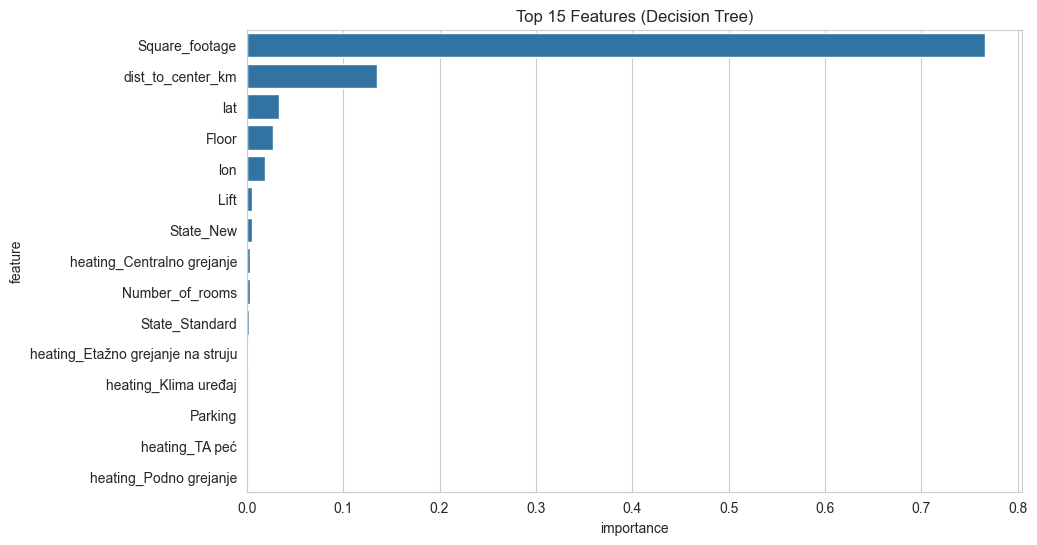

In [52]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=feat_imp_dt.head(15),
    x="importance",
    y="feature"
)
plt.title("Top 15 Features (Decision Tree)")
plt.show()

                       feature  importance
5               Square_footage    0.706956
23           dist_to_center_km    0.126444
10                       Floor    0.040385
22                         lon    0.035687
21                         lat    0.032482
6              Number_of_rooms    0.014830
7                         Lift    0.009817
2                    State_New    0.005861
11  heating_Centralno grejanje    0.004644
20        heating_Klima uređaj    0.004031


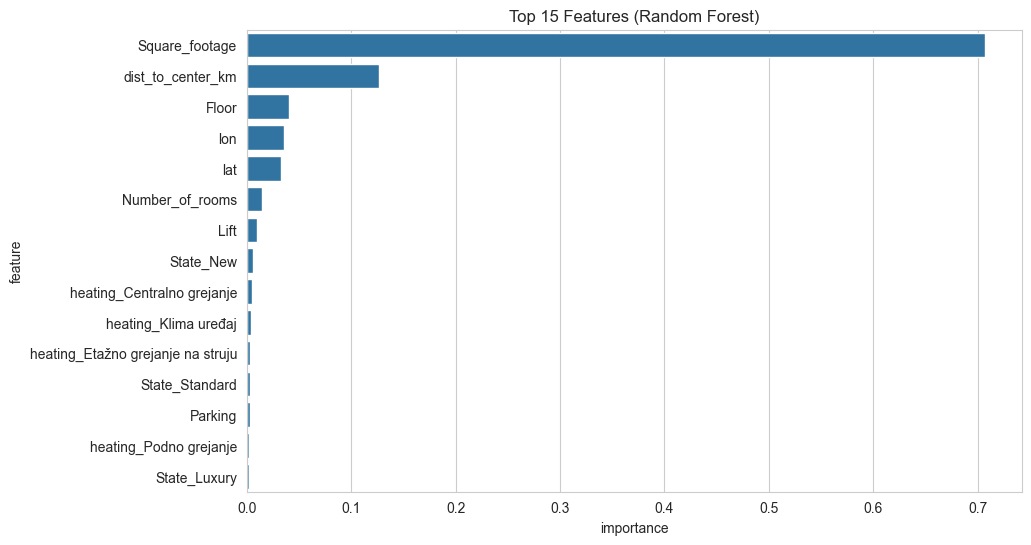

In [53]:
# Random Forest feature importance
best_rf = random_search_rf.best_estimator_   # ← ovo je bila typo greška

feature_names = get_feature_names(
    best_rf.named_steps["preprocessor"],
    numerical_cols,
    categorical_cols
)

importances = best_rf.named_steps["regressor"].feature_importances_

feat_imp_rf = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(feat_imp_rf.head(10))

plt.figure(figsize=(10,6))
sns.barplot(data=feat_imp_rf.head(15), x="importance", y="feature")
plt.title("Top 15 Features (Random Forest)")
plt.show()

In [54]:
#Xgboost 
# Get feature names
best_xgb = random_search_xgb.best_estimator_

feature_names = get_feature_names(
    best_xgb.named_steps["preprocessor"],
    numerical_cols,
    categorical_cols
)

# Get importances
importances = best_xgb.named_steps["regressor"].feature_importances_

# Create dataframe
feat_imp_xgb = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(feat_imp_xgb.head(10))

                   feature  importance
5           Square_footage    0.267272
6          Number_of_rooms    0.110696
23       dist_to_center_km    0.098704
22                     lon    0.076844
21                     lat    0.053410
16  heating_Toplotna pumpa    0.047565
7                     Lift    0.036882
10                   Floor    0.033766
2                State_New    0.029302
17          heating_TA peć    0.027892


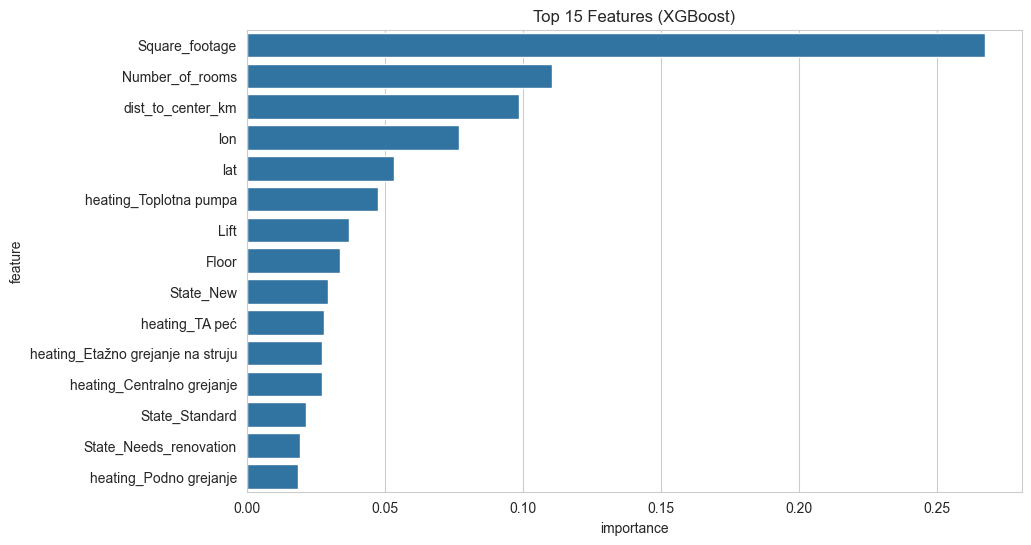

In [55]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=feat_imp_xgb.head(15),
    x="importance",
    y="feature"
)
plt.title("Top 15 Features (XGBoost)")
plt.show()

In [56]:
# Linear regression: 
feature_names = lr_pipeline.named_steps["preprocessor"].get_feature_names_out()

coefficients = lr_pipeline.named_steps["regressor"].coef_

feat_imp_lr = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

# Sort by absolute importance
feat_imp_lr["abs_coef"] = feat_imp_lr["coefficient"].abs()
feat_imp_lr = feat_imp_lr.sort_values(by="abs_coef", ascending=False)

print(feat_imp_lr.head(10))

                        feature    coefficient       abs_coef
0           num__Square_footage  178955.365804  178955.365804
18       num__dist_to_center_km  -47722.882243   47722.882243
19            cat__State_Luxury   33568.543501   33568.543501
1          num__Number_of_rooms  -22707.521399   22707.521399
20  cat__State_Needs_renovation  -20827.193187   20827.193187
5                    num__Floor   18372.179211   18372.179211
21               cat__State_New   17254.983502   17254.983502
23          cat__State_Standard  -17156.608586   17156.608586
17                     num__lon  -13258.672300   13258.672300
22         cat__State_Renovated  -12839.725230   12839.725230


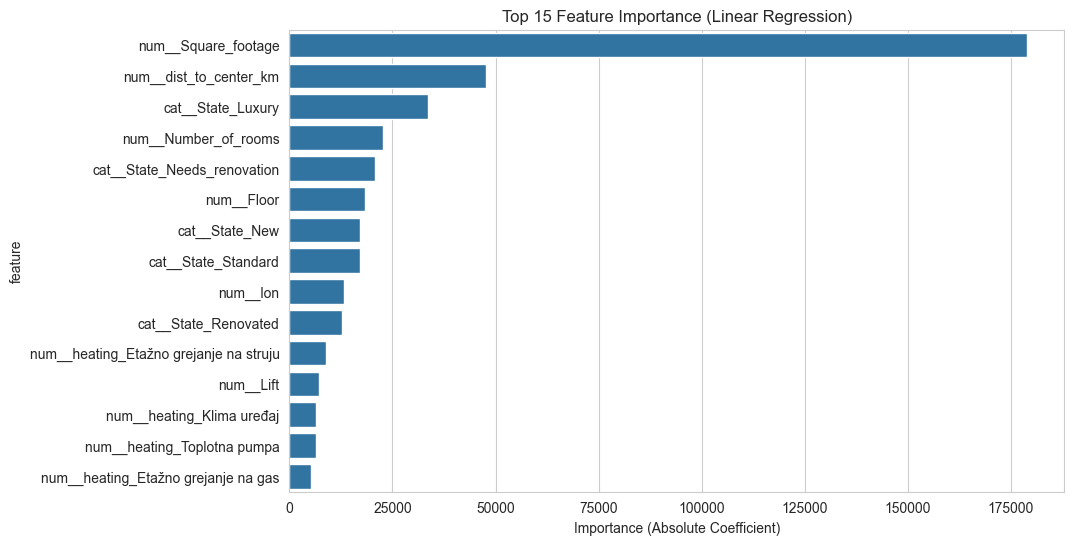

In [57]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=feat_imp_lr.head(15),
    x="abs_coef",
    y="feature"
)
plt.title("Top 15 Feature Importance (Linear Regression)")
plt.xlabel("Importance (Absolute Coefficient)")
plt.show()